In [137]:
# Aquí de desarrollará el código para el modelo de DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

# Importamos las librerías necesarias
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset df_dqi_final
df_dqi_final = pd.read_csv('./Data/Processed/df_dqi_final.csv', delimiter=';')

Se analizan las características del dataset **df_dqi_final**

In [138]:
# Visualizamos los primeros registros
df_dqi_final.head()


,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,False,True,False,False,False,False,False,True,False,False
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,False,True,False,False,False,False,False,True,False,False
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,False,True,False,False,False,False,False,True,False,False


In [139]:
# shape del dataset
df_dqi_final.shape

(638, 37)

In [140]:
df_dqi_final.describe()

,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,...,dqi_adequacy_fiber,dqi_adequacy_protein,dqi_adequacy_calcium,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total,edad,ponderador,resultado_general_entrevista
count,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,...,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,638.000000,6.380000e+02,638.0
mean,0.796238,0.112853,0.909091,1.147335,1.034483,0.893417,4.123824,5.943574,13.142633,9.987461,...,3.186520,4.805643,3.172414,2.952978,3.873041,24.255486,51.810345,39.985893,1.115890e+05,1.0
std,1.574677,0.513361,1.616597,1.977166,1.723073,1.678543,2.525604,0.472092,5.060392,4.200602,...,1.633059,0.592867,1.476681,1.712723,1.631093,8.509977,12.880324,13.303537,1.340553e+05,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000,19.000000,18.000000,7.032174e+03,1.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,6.000000,9.000000,6.000000,...,2.000000,5.000000,2.000000,1.000000,3.000000,18.000000,42.000000,28.000000,3.160034e+04,1.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,6.000000,12.000000,12.000000,...,3.000000,5.000000,3.000000,3.000000,5.000000,25.000000,53.000000,40.000000,6.486087e+04,1.0
75%,0.000000,0.000000,2.000000,3.000000,3.000000,0.000000,6.000000,6.000000,15.000000,12.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,61.000000,51.000000,1.352364e+05,1.0
max,6.000000,4.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,30.000000,15.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,40.000000,84.000000,64.000000,1.145273e+06,1.0


In [141]:
# cantidad de variables numericas y categoricas
df_dqi_final.dtypes.value_counts()

int64      24
bool       10
object      2
float64     1
Name: count, dtype: int64

In [142]:
# La mayor parte de los datos booleanos del dataset son datos demograficos y no se consideraran para el modelo
boolean_columns = df_dqi_final.select_dtypes(include=['bool']).columns
print(boolean_columns)

Index(['region_Centro', 'region_Centro Norte', 'region_Frontera',
       'region_Pacifico-Norte', 'region_Pacífico Sur',
       'region_Pacífico-Centro', 'region_Península', 'sexo_Mujer',
       'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'],
      dtype='object')


In [143]:
# Lista de columnas en df_dqi_final
df_dqi_final.columns

Index(['folio_integrante', 'macronutrients_dqi', 'fatty_acids_dqi',
       'balance_dqi', 'empty_calories_dqi', 'total_fat_dqi',
       'saturated_fat_dqi', 'cholesterol_dqi', 'sodium_dqi', 'moderation_dqi',
       'dqi_food_groups', 'dqi_protein_sources', 'variety_dqi',
       'dqi_adequacy_fruits', 'dqi_adequacy_vegetables', 'dqi_adequacy_grains',
       'dqi_adequacy_fiber', 'dqi_adequacy_protein', 'dqi_adequacy_calcium',
       'dqi_adequacy_iron', 'dqi_adequacy_vitamin_c', 'dqi_adecuacy',
       'dqi_total', 'edad', 'ponderador', 'grupo',
       'resultado_general_entrevista', 'region_Centro', 'region_Centro Norte',
       'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur',
       'region_Pacífico-Centro', 'region_Península', 'sexo_Mujer',
       'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'],
      dtype='object')

Eliminamos las vairables que no son relevantes para el análisis para reducir las dimensiones a analizar con DBSCAN

In [144]:
## Eliminar columnas que no se utilizarán en el proceso de clustering
df_clustering_pca = df_dqi_final.copy()
columns_to_drop = ['folio_integrante', 'ponderador', 'grupo', 'resultado_general_entrevista'] + list(boolean_columns)
df_clustering_pca.drop(columns=columns_to_drop, inplace=True)

Nos aseguramos en el código anterior de que no exitan datos nulos

In [145]:
# Revisando valores nulos en el dataset
null_counts = df_dqi_final.isnull().sum()
#print(null_counts)

if null_counts.sum() > 0:
    print("Se encontraron datos nulos en el dataset.")
else:
    print("No se encontraron datos nulos en el dataset.")

No se encontraron datos nulos en el dataset.


DBSCAN es un modelo que se sugiere solo trabajar con variables numéricas y para fines prácticos y debido al gran tamaño del dataset se descartarán categóricas y booleanas. 


In [146]:
# Eliminamos las columnas que no son numericas
df_dqi_final = df_dqi_final.select_dtypes(include=[np.number])

# Mostramos el dataset con las columnas numericas
df_dqi_final.head()

,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,...,dqi_adequacy_fiber,dqi_adequacy_protein,dqi_adequacy_calcium,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total,edad,ponderador,resultado_general_entrevista
0,0,0,0,0,0,0,6,6,12,12,...,4,5,5,2,5,31,60,51,8717.185479,1
1,0,0,0,3,0,0,0,6,9,12,...,5,5,5,3,5,32,58,26,51475.173556,1
2,0,0,0,3,0,0,0,6,9,15,...,5,5,4,3,5,31,60,62,7032.174356,1
3,0,0,0,0,0,0,0,6,6,9,...,3,5,3,2,2,20,40,33,27374.852298,1
4,0,0,0,0,0,0,0,6,6,15,...,5,5,5,5,5,37,63,60,15823.033532,1


## Analisis de PCA previo a modelo DBSAN

In [148]:

# Normalización del dataset
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_clustering_pca)

# Aplicar PCA para reducir la dimensionalidad
pca = PCA(n_components=0.9)  # varianza del 90%
pca_data = pca.fit_transform(scaled_data)

# Aplicar DBSCAN con diferentes combinaciones de eps y min_samples
eps_values = np.arange(0.1, 3.0, 0.1)  # Desde 0.1 hasta 3.0, con incrementos de 0.1
min_samples_values = [3, 5, 7, 10, 15, 20, 25]

best_silhouette = -1
best_eps = None
best_min_samples = None
best_labels = None

In [149]:
# Iterar a través de diferentes combinaciones de eps y min_samples para encontrar el mejor puntaje de silueta
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(pca_data)
        
        # Filtrar puntos de ruido (-1 labels)
        if len(set(labels)) > 1:  # Al menos 2 clusters deben estar presentes
            silhouette_avg = silhouette_score(pca_data, labels)
            print(f'eps = {eps}, min_samples = {min_samples}, Silhouette Score = {silhouette_avg}')
            
            if silhouette_avg > best_silhouette:
                best_silhouette = silhouette_avg
                best_eps = eps
                best_min_samples = min_samples
                best_labels = labels

print(f'\nBest DBSCAN Configuration: eps = {best_eps}, min_samples = {best_min_samples}, Silhouette Score = {best_silhouette}')


eps = 0.2, min_samples = 3, Silhouette Score = -0.1570436408505282
eps = 0.2, min_samples = 5, Silhouette Score = -0.016654571740230908
eps = 0.30000000000000004, min_samples = 3, Silhouette Score = -0.29356078808884395
eps = 0.30000000000000004, min_samples = 5, Silhouette Score = -0.03232808426584463
eps = 0.30000000000000004, min_samples = 7, Silhouette Score = 0.01667336920751203
eps = 0.30000000000000004, min_samples = 10, Silhouette Score = -0.005609808033749279
eps = 0.4, min_samples = 3, Silhouette Score = -0.26907788957750367
eps = 0.4, min_samples = 5, Silhouette Score = -0.25414295320837715
eps = 0.4, min_samples = 7, Silhouette Score = 0.026722504801648592
eps = 0.4, min_samples = 10, Silhouette Score = 0.018036411624289025
eps = 0.4, min_samples = 15, Silhouette Score = 0.02889426663792389
eps = 0.4, min_samples = 20, Silhouette Score = 0.002997346927562107
eps = 0.5, min_samples = 3, Silhouette Score = -0.2066569590510288
eps = 0.5, min_samples = 5, Silhouette Score = -0.

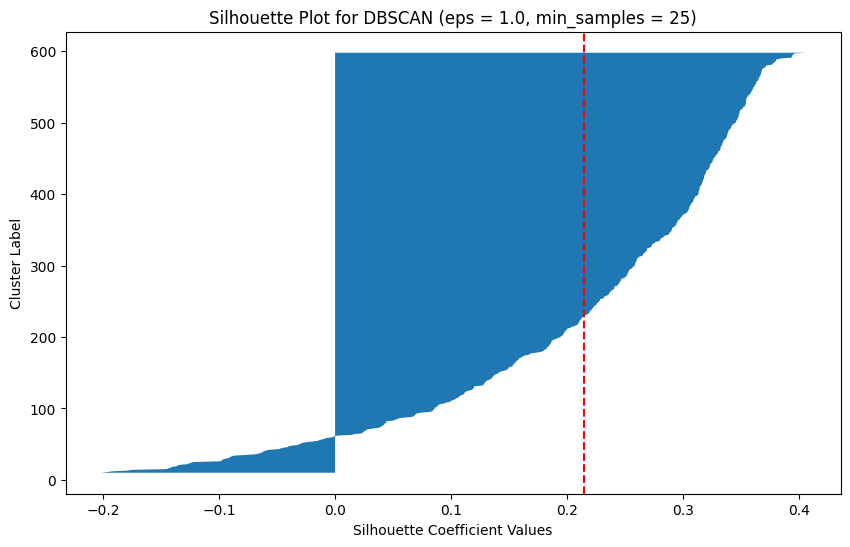

In [150]:
# Graficar Análisis de Silueta para el Mejor DBSCAN
if best_labels is not None:
    unique_labels = set(best_labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    silhouette_vals = silhouette_samples(pca_data, best_labels)
    
    y_lower = 10
    for i, label in enumerate(unique_labels):
        if label == -1:
            continue  # Saltar puntos de ruido
        cluster_silhouette_vals = silhouette_vals[best_labels == label]
        cluster_silhouette_vals.sort()
        y_upper = y_lower + len(cluster_silhouette_vals)

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals)
        y_lower = y_upper + 10

    ax.set_title(f'Silhouette Plot for DBSCAN (eps = {best_eps}, min_samples = {best_min_samples})')
    ax.set_xlabel('Silhouette Coefficient Values')
    ax.set_ylabel('Cluster Label')
    ax.axvline(x=best_silhouette, color="red", linestyle="--")
    plt.show()

In [151]:
# Graficar Chart Radar para los Centros de Clusters
def plot_radar_chart(df, labels):
    cluster_data = pd.concat([df, pd.Series(labels, name='Cluster')], axis=1)
    cluster_centers = cluster_data.groupby('Cluster').mean()
    
    if -1 in cluster_centers.index:  # Remover puntos de ruido si están presentes
        cluster_centers = cluster_centers.drop(index=-1)

    categories = cluster_centers.columns
    num_vars = len(categories)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for idx, row in cluster_centers.iterrows():
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Cluster {idx}')
        ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_title('Radar Chart for Cluster Centers')
    ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    plt.show()

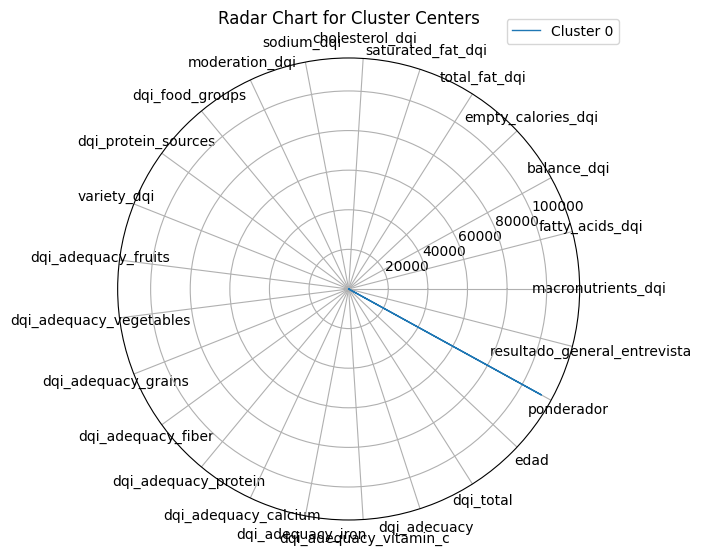

In [152]:
# Graficar Radar Chart para los Clusters encontrados por DBSCAN
plot_radar_chart(df_dqi_final, best_labels)